# Import Environment variables

In [2]:
%run /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables.ipynb

Found bucket: id=rw-migration-aou-rw-f7a4d148, bucketName=rw-migration-aou-rw-f7a4d148
-> Assigned migration variables (ID: rw-migration-aou-rw-f7a4d148)
Found bucket: id=temporary-workspace-bucket, bucketName=temporary-workspace-bucket-wb-perky-cabbage-8342
Found bucket: id=workspace-bucket, bucketName=workspace-bucket-wb-perky-cabbage-8342
✅ Successfully identified latest dataset: wb-silky-artichoke-2408.C2024Q3R9

Variables extracted:
GOOGLE_CLOUD_PROJECT: wb-perky-cabbage-8342
WORKSPACE_BUCKET: gs://workspace-bucket-wb-perky-cabbage-8342
WORKSPACE_TEMP_BUCKET: gs://temporary-workspace-bucket-wb-perky-cabbage-8342
WORKSPACE_CDR: wb-silky-artichoke-2408.C2024Q3R9
bucket_aou_tutorial: NOT FOUND
bucket_id_aou_tutorial: NOT FOUND
bucket_migrated: gs://rw-migration-aou-rw-f7a4d148
bucket_id_migrated: rw-migration-aou-rw-f7a4d148

✅ Saved to /home/jupyter/.bashrc
C2024Q3R9 BQ_DATASET
Multi-trait-GWAS-in-admixed-populations GIT_REPO
dataset_test2 BQ_DATASET
prep_C2024Q3R9 BQ_DATASET
rw-mig

In [3]:
%run /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables_p2.ipynb

WORKSPACE_CDR = wb-silky-artichoke-2408.C2024Q3R9
WORKSPACE_BUCKET = gs://workspace-bucket-wb-perky-cabbage-8342
GOOGLE_PROJECT = wb-perky-cabbage-8342
Done! 10 variables saved to: /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables_p2.R
Done! 10 variables saved to: /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables.sas


# Import library

In [4]:
%load_ext autoreload
%autoreload 2
    
import os
import subprocess
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

# Importation des données issues du notebook `53_BC_WITHIN_5Y_FamilyHistory_Treatment`

In [5]:
# get the bucket name
my_bucket = os.getenv('WORKSPACE_TEMP_BUCKET')

name_of_file_in_bucket = "df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry_biopsy_FamilyHistory.tsv"

df_bc = pd.read_csv(my_bucket +'/'+ name_of_file_in_bucket, sep=',', low_memory=False)
df_bc

,person_id,gender,date_of_birth,ethnicity,self_reported_category,inclusion_date,first_breast_cancer_date,delay_days,delay_years,time_category,...,first_survey_date,last_survey_date,days_last_survey_to_first_survey,Daughter,Mother,Sibling,days_inclusion_to_first_survey,days_inclusion_to_last_survey,days_has_bc_to_first_survey,days_has_bc_to_last_survey
0,7604109,Female,1953-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-03-29,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2382559,Female,1988-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2022-04-04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2032331,Female,1954-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2019-09-17,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3382692,Female,1957-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2018-07-17,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2537673,Female,1965-06-15,Not Hispanic or Latino,Native Hawaiian or Other Pacific Islander,2019-03-04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223201,8122695,Female,2002-06-15,Not Hispanic or Latino,White,2023-06-21,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
223202,3902303,Female,2003-06-15,Not Hispanic or Latino,White,2022-12-12,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
223203,9743793,Female,2003-06-15,Not Hispanic or Latino,White,2022-12-27,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
223204,4702863,Female,2003-06-15,Not Hispanic or Latino,White,2023-02-24,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Verification of relatedness

## relatedness_flagged_samples

### Data import

In [6]:
!gcloud storage ls gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/relatedness --billing-project=$GOOGLE_PROJECT

gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/relatedness/samples_relatedness.tsv
gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/relatedness/samples_relatedness_flagged_samples.tsv


In [7]:
!gcloud storage cp gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/relatedness/samples_relatedness_flagged_samples.tsv $WORKSPACE_TEMP_BUCKET/ --billing-project=$GOOGLE_PROJECT

Copying gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/relatedness/samples_relatedness_flagged_samples.tsv to gs://temporary-workspace-bucket-wb-perky-cabbage-8342/samples_relatedness_flagged_samples.tsv
  Completed files 1/1 | 238.9kiB/238.9kiB                                      


In [8]:
destination_filename = 'samples_relatedness_flagged_samples.tsv'

my_bucket = os.getenv('WORKSPACE_TEMP_BUCKET')

df_relatedness_flagged = pd.read_csv(my_bucket +'/'+ destination_filename)

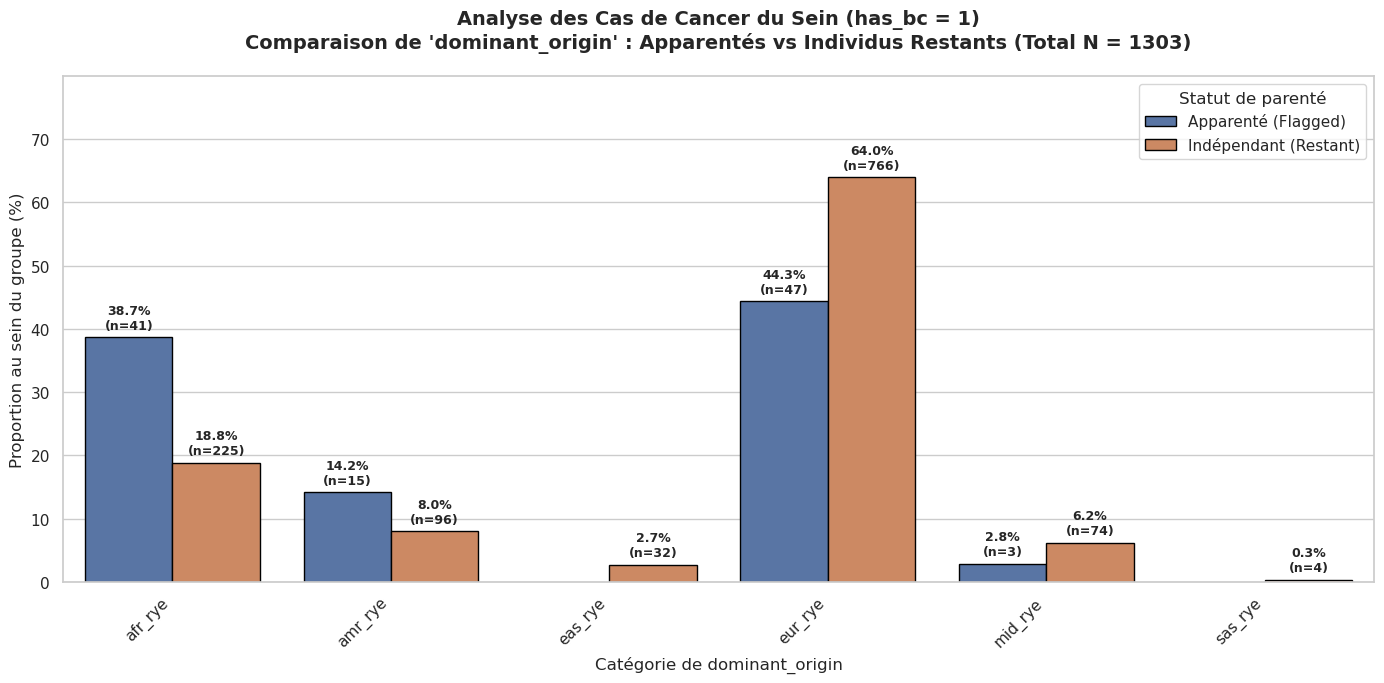

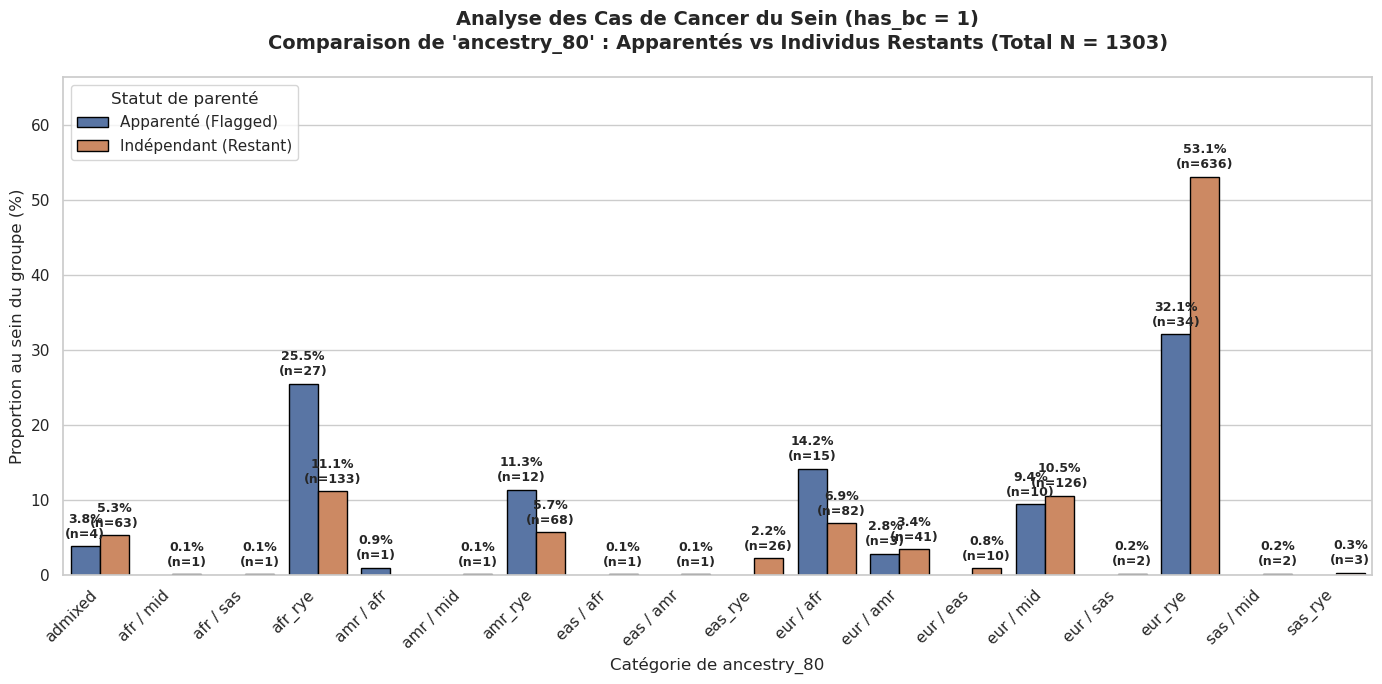

  TABLEAUX DE VÉRIFICATION DES EFFECTIFS (POPULATION HAS_BC = 1)   

--- Répartition croisée pour la variable : dominant_origin ---


statut_parente,Apparenté (Flagged),Indépendant (Restant),All
dominant_origin,,,
afr_rye,41,225,266
amr_rye,15,96,111
eas_rye,0,32,32
eur_rye,47,766,813
mid_rye,3,74,77
sas_rye,0,4,4
All,106,1197,1303



--- Répartition croisée pour la variable : ancestry_80 ---


statut_parente,Apparenté (Flagged),Indépendant (Restant),All
ancestry_80,,,
admixed,4,63,67
afr / mid,0,1,1
afr / sas,0,1,1
afr_rye,27,133,160
amr / afr,1,0,1
amr / mid,0,1,1
amr_rye,12,68,80
eas / afr,0,1,1
eas / amr,0,1,1


--- RÉPARTITION GLOBALE DES CAS ---
statut_parente
Indépendant (Restant)    1197
Apparenté (Flagged)       106
Name: count, dtype: int64

En pourcentages :
statut_parente
Indépendant (Restant)    91.864927
Apparenté (Flagged)       8.135073
Name: proportion, dtype: float64


In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1️⃣ Filtrage et Marquage
df_cases = df_bc[df_bc["has_bc"] == 1].copy()
N_total_cases = len(df_cases)

df_cases["statut_parente"] = np.where(
    df_cases["person_id"].isin(df_relatedness_flagged["sample_id"]),
    "Apparenté (Flagged)",
    "Indépendant (Restant)",
)

ordre_statuts = ["Apparenté (Flagged)", "Indépendant (Restant)"]
colonnes_ancestry = ["dominant_origin", "ancestry_80"]

sns.set_theme(style="whitegrid")

for col in colonnes_ancestry:
    plt.figure(figsize=(14, 7))

    # Calcul des proportions
    df_pct = (
        df_cases.groupby("statut_parente")[col]
        .value_counts(normalize=True)
        .mul(100)
        .rename("Pourcentage (%)")
        .reset_index()
    )

    # Récupération de l'ordre exact et complet des catégories (Axe X)
    ordre_x = sorted(df_cases[col].dropna().unique())

    # Création du graphique
    ax = sns.barplot(
        data=df_pct,
        x=col,
        y="Pourcentage (%)",
        hue="statut_parente",
        order=ordre_x,
        hue_order=ordre_statuts,
        edgecolor="black",
    )

    # 3️⃣ Ajout dynamique des proportions (%) ET des effectifs (n) SÉCURISÉ
    for i, container in enumerate(ax.containers):
        groupe_actuel = ordre_statuts[i]

        for bar in container:
            pct = bar.get_height()
            
            # np.isnan vérifie si la barre existe mathématiquement. 
            # pct > 0 empêche d'écrire "0% (n=0)" sur le graphique pour ne pas le surcharger.
            if not np.isnan(pct) and pct > 0:
                
                # --- LA CORRECTION EST ICI ---
                # On récupère la coordonnée X exacte de la barre et on l'arrondit
                # pour trouver à quel index de "ordre_x" elle correspond !
                index_categorie = int(round(bar.get_x() + bar.get_width() / 2.0))
                
                # Sécurité : on s'assure de ne pas dépasser la liste (bien que Seaborn gère l'alignement)
                if 0 <= index_categorie < len(ordre_x):
                    categorie_actuelle = ordre_x[index_categorie]

                    # Calcul de l'effectif avec le bon groupe ET la bonne catégorie
                    count = len(
                        df_cases[
                            (df_cases["statut_parente"] == groupe_actuel)
                            & (df_cases[col] == categorie_actuelle)
                        ]
                    )

                    # Affichage du texte
                    ax.annotate(
                        f"{pct:.1f}%\n(n={count})",
                        (bar.get_x() + bar.get_width() / 2.0, pct),
                        ha="center",
                        va="center",
                        xytext=(0, 14),
                        textcoords="offset points",
                        fontsize=9,
                        fontweight="bold",
                    )

    plt.title(
        f"Analyse des Cas de Cancer du Sein (has_bc = 1)\n"
        f"Comparaison de '{col}' : Apparentés vs Individus Restants (Total N = {N_total_cases})",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )
    plt.xlabel(f"Catégorie de {col}", fontsize=12)
    plt.ylabel("Proportion au sein du groupe (%)", fontsize=12)

    plt.ylim(0, df_pct["Pourcentage (%)"].max() * 1.25)
    plt.xticks(rotation=45, ha='right')  # ha='right' pour un texte en biais plus lisible
    plt.legend(title="Statut de parenté")
    plt.tight_layout()
    plt.show()

# 5️⃣ Les tables de contingence restent les mêmes pour ta double vérification
print("====================================================================")
print("  TABLEAUX DE VÉRIFICATION DES EFFECTIFS (POPULATION HAS_BC = 1)   ")
print("====================================================================")
for col in colonnes_ancestry:
    print(f"\n--- Répartition croisée pour la variable : {col} ---")
    display(pd.crosstab(df_cases[col], df_cases["statut_parente"], margins=True))

# 4. Affichage du décompte global textuel pour ton rapport
print("--- RÉPARTITION GLOBALE DES CAS ---")
print(df_cases["statut_parente"].value_counts())
print("\nEn pourcentages :")
print(df_cases["statut_parente"].value_counts(normalize=True) * 100)

## samples_relatedness

In [10]:
!gcloud storage cp gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/relatedness/samples_relatedness.tsv $WORKSPACE_TEMP_BUCKET/ --billing-project=$GOOGLE_PROJECT

Copying gs://vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/relatedness/samples_relatedness.tsv to gs://temporary-workspace-bucket-wb-perky-cabbage-8342/samples_relatedness.tsv
  Completed files 1/1 | 1.0MiB/1.0MiB                                          


In [11]:
destination_filename = 'samples_relatedness.tsv'

my_bucket = os.getenv('WORKSPACE_TEMP_BUCKET')

df_samples_relatedness = pd.read_csv(my_bucket +'/'+ destination_filename, sep='\t')

array([[<Axes: title={'center': 'kin'}>]], dtype=object)

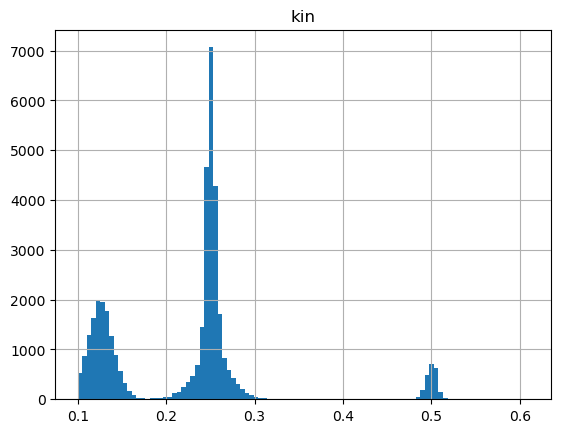

In [17]:
df_samples_relatedness.hist('kin', bins=100)

# Sélection des individus ayant une date de cancer du sein > 180 jours après l'inclusion (3 mois)

# Sélection des individus ayant eu une biopsie < 180 jours avant la date d'inclusion (3 mois)

# Faire colonne délai entre date de cancer et date de questionnaire

# Garder les femmes de 42 à 72 (ou 37 à 42 et ainsi de suite...)

# Data's export

In [ ]:
destination_filename = 'Datas/df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry_biopsy_FamilyHistory.tsv'
df.to_csv(destination_filename, index=False)

# Récupère le nom du bucket Google Cloud depuis la variable d’environnement
my_bucket = os.getenv('WORKSPACE_TEMP_BUCKET')

# Copie le fichier TSV local dans le dossier "Data" du bucket
args = ["gsutil", "cp", f"./{destination_filename}", f"{my_bucket}"]
output = subprocess.run(args, capture_output=True)

# Affiche les éventuelles erreurs retournées par gsutil
output.stderr